# Pricer and Greeks

Exercises `pricing.py` and `greeks.py`, the two modules everything else in this project is built on. Pure functions, no market data, nothing here needs internet.

In [14]:
import sys

sys.path.insert(0, "..")  # optionsengine lives one level up, next to notebooks/

import numpy as np
import matplotlib.pyplot as plt
from optionsengine.pricing import bs_price, forward_price
from optionsengine.greeks import all_greeks, delta, gamma, theta
from optionsengine.config import r

## The model

Plain Black-Scholes: a European call or put on an underlying with no dividends, constant
volatility, constant interest rate.

$$
C = S \, N(d_1) - K e^{-rT} N(d_2) \qquad\qquad
P = K e^{-rT} N(-d_2) - S \, N(-d_1)
$$

$$
d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)\,T}{\sigma\sqrt{T}} \qquad\qquad
d_2 = d_1 - \sigma\sqrt{T}
$$

$N$ is the standard normal CDF. $S$ is the spot price, $K$ the strike, $T$ the time to
expiry in years, $r$ the risk-free rate, $\sigma$ the volatility.

## Checked against a textbook

Hull, *Options, Futures and Other Derivatives*: spot 42, strike 40, 6 months to expiry,
10% rate, 20% vol. The book quotes call = 4.76, put = 0.81.

In [15]:
call = bs_price(S=42, K=40, T=0.5, r=0.10, sigma=0.20, option_type="call")
put = bs_price(S=42, K=40, T=0.5, r=0.10, sigma=0.20, option_type="put")
print(f"call = {call:.2f}  (Hull: 4.76)")
print(f"put  = {put:.2f}  (Hull: 0.81)")

call = 4.76  (Hull: 4.76)
put  = 0.81  (Hull: 0.81)


## Put-call parity

$C - P = S - Ke^{-rT}$ holds for any inputs. It comes from a no-arbitrage argument, not
from Black-Scholes itself, so it's a genuinely independent check on both formulas.

In [16]:
lhs = call - put
rhs = 42 - 40 * np.exp(-0.10 * 0.5)
print(f"C - P          = {lhs:.6f}")
print(f"S - K*exp(-rT) = {rhs:.6f}")

C - P          = 3.950823
S - K*exp(-rT) = 3.950823


## Price against strike

From here on, one running example: spot 7700 (today's SPX level), 6 months to expiry,
18% vol. Strikes are centred on the forward price `F = S*exp(rT)`, not spot. That's the same
convention the rest of the project uses for "at the money."

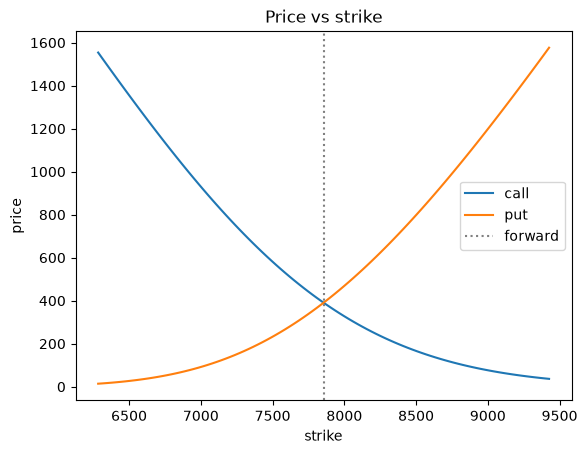

In [17]:
S, T, sigma = 7700.0, 0.5, 0.18
F = forward_price(S, T, r)
strikes = np.linspace(0.8 * F, 1.2 * F, 100)  # same moneyness window the live chain uses

call_prices = [bs_price(S, K, T, r, sigma, "call") for K in strikes]
put_prices = [bs_price(S, K, T, r, sigma, "put") for K in strikes]

fig, ax = plt.subplots()
ax.plot(strikes, call_prices, label="call")
ax.plot(strikes, put_prices, label="put")
ax.axvline(F, linestyle=":", color="grey", label="forward")
ax.set_title("Price vs strike")
ax.set_xlabel("strike")
ax.set_ylabel("price")
ax.legend()
plt.show()

## Two edge cases

`bs_price` handles zero volatility and zero time specially instead of letting the formula
divide by zero.

- **T = 0**: the option has expired, worth its raw intrinsic value, `max(S-K, 0)`.
- **sigma = 0**: no uncertainty left, so the payoff is already known. But it isn't paid
  until expiry, so the strike is discounted: `max(S - K*exp(-rT), 0)`, not `max(S-K, 0)`.
  Getting this wrong breaks the IV solver's lower bound (see `implied_vol.py`).

In [18]:
K = 7800.0
print("T = 0,     call:", bs_price(S, K, 0.0, r, sigma, "call"),
      " vs raw intrinsic       ", max(S - K, 0.0))
print("sigma = 0, call:", bs_price(S, K, T, r, 0.0, "call"),
      " vs discounted intrinsic", max(S - K * np.exp(-r * T), 0.0))

T = 0,     call: 0.0  vs raw intrinsic        0.0
sigma = 0, call: 54.45034820730871  vs discounted intrinsic 54.45034820730871


## Greeks

Each Greek is a derivative of the price with respect to one input.

$$
\Delta = \frac{\partial V}{\partial S} \qquad
\Gamma = \frac{\partial^2 V}{\partial S^2} \qquad
\nu = \frac{\partial V}{\partial \sigma} \qquad
\Theta = \frac{\partial V}{\partial T} \qquad
\rho = \frac{\partial V}{\partial r}
$$

Gamma and vega take no option type in the code. A call and a put at the same strike and
expiry differ only by a forward, which is a straight line in $S$ with no volatility in it,
so curvature and volatility sensitivity have to match exactly. Checked numerically below.

In [19]:
K_atm = F  # at the money means K = F, not K = S
g_call = all_greeks(S, K_atm, T, r, sigma, "call")
g_put = all_greeks(S, K_atm, T, r, sigma, "put")

print(f"{'':8}{'call':>12}{'put':>12}")
for name in ("delta", "gamma", "vega", "theta", "rho"):
    print(f"{name:<8}{getattr(g_call, name):12.4f}{getattr(g_put, name):12.4f}")

                call         put
delta         0.5254     -0.4746
gamma         0.0004      0.0004
vega       2167.7358   2167.7358
theta      -536.3780   -228.3780
rho        1827.3201  -2022.6799


## Greeks against strike

Delta traces an S-curve from 0 to 1 (call) or -1 to 0 (put). Gamma and vega both peak at
the money and fall away on both sides, and for fixed S, T, sigma they're exactly
proportional (vega = gamma * S^2*sigma*T), so one plot covers both. Theta is usually most
negative near the money too: that's where there's the most time value to lose.

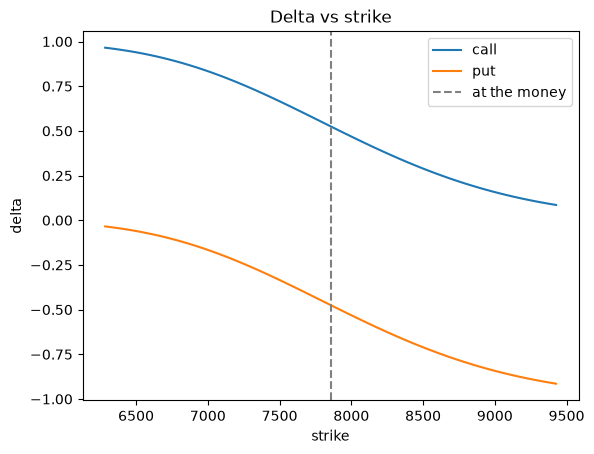

In [20]:
deltas_call = [delta(S, K, T, r, sigma, "call") for K in strikes]
deltas_put = [delta(S, K, T, r, sigma, "put") for K in strikes]

fig, ax = plt.subplots()
ax.plot(strikes, deltas_call, label="call")
ax.plot(strikes, deltas_put, label="put")
ax.axvline(F, linestyle="--", color="grey", label="at the money")
ax.set_title("Delta vs strike")
ax.set_xlabel("strike")
ax.set_ylabel("delta")
ax.legend()
plt.show()

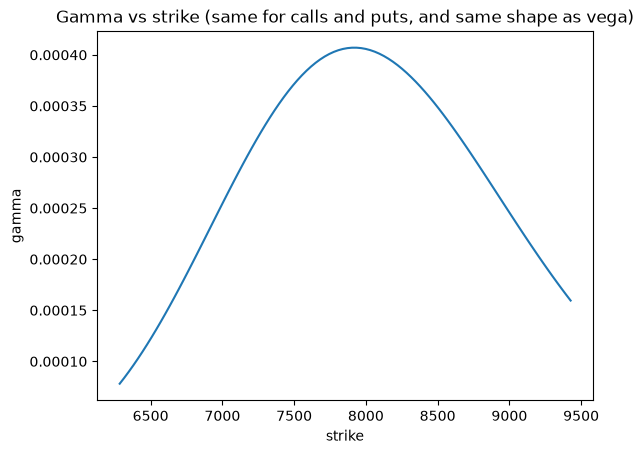

In [21]:
gammas = [gamma(S, K, T, r, sigma) for K in strikes]

fig, ax = plt.subplots()
ax.plot(strikes, gammas)
ax.set_title("Gamma vs strike (same for calls and puts, and same shape as vega)")
ax.set_xlabel("strike")
ax.set_ylabel("gamma")
plt.show()

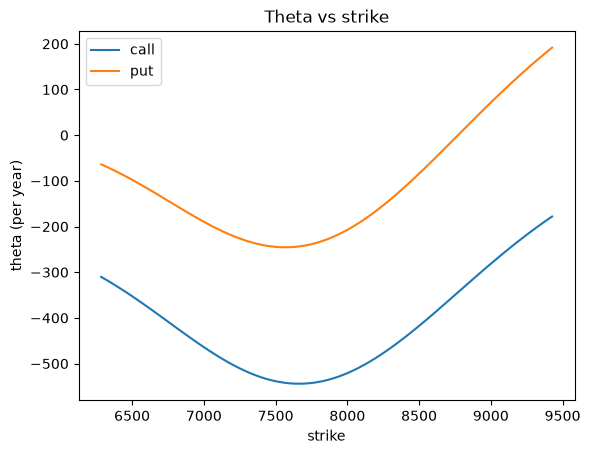

In [22]:
thetas_call = [theta(S, K, T, r, sigma, "call") for K in strikes]
thetas_put = [theta(S, K, T, r, sigma, "put") for K in strikes]

fig, ax = plt.subplots()
ax.plot(strikes, thetas_call, label="call")
ax.plot(strikes, thetas_put, label="put")
ax.set_title("Theta vs strike")
ax.set_xlabel("strike")
ax.set_ylabel("theta (per year)")
ax.legend()
plt.show()

## Time decay accelerates near expiry

Same at-the-money option, theta against time to expiry instead of strike. The closer to
expiry, the faster the option loses value each day. Theta gets steeper, not steeper at
a constant rate.

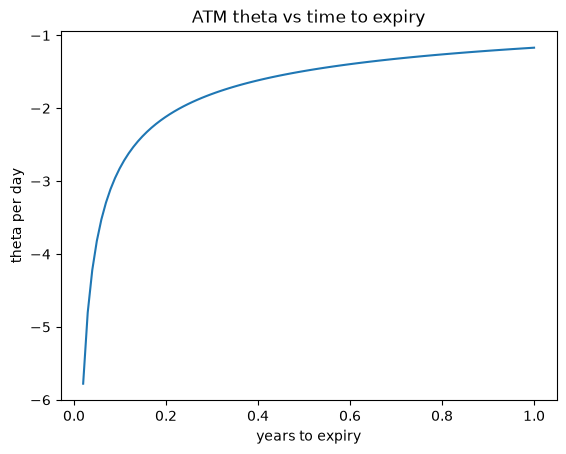

In [23]:
times = np.linspace(0.02, 1.0, 100)
thetas_atm = [theta(S, S, T_i, r, sigma, "call") / 365 for T_i in times]  # per day

fig, ax = plt.subplots()
ax.plot(times, thetas_atm)
ax.set_title("ATM theta vs time to expiry")
ax.set_xlabel("years to expiry")
ax.set_ylabel("theta per day")
plt.show()

## Checked against finite differences

Same strategy the test suite uses: bump the price function itself and compare against the
closed form. Independent of the algebra in `greeks.py`. A sign error or a missing
`exp(-rT)` would show up here even if it never showed up in the closed-form derivation.

In [24]:
def fd_delta(S, K, T, r, sigma, option_type, h=1e-4):
    return (bs_price(S + h, K, T, r, sigma, option_type)
            - bs_price(S - h, K, T, r, sigma, option_type)) / (2 * h)


def fd_gamma(S, K, T, r, sigma, option_type, h=1e-3):
    return (bs_price(S + h, K, T, r, sigma, option_type)
            - 2 * bs_price(S, K, T, r, sigma, option_type)
            + bs_price(S - h, K, T, r, sigma, option_type)) / h**2


def fd_vega(S, K, T, r, sigma, option_type, h=1e-4):
    return (bs_price(S, K, T, r, sigma + h, option_type)
            - bs_price(S, K, T, r, sigma - h, option_type)) / (2 * h)


print(f"delta  closed {g_call.delta:.6f}  finite-diff {fd_delta(S, K_atm, T, r, sigma, 'call'):.6f}")
print(f"gamma  closed {g_call.gamma:.6f}  finite-diff {fd_gamma(S, K_atm, T, r, sigma, 'call'):.6f}")
print(f"vega   closed {g_call.vega:.6f}  finite-diff {fd_vega(S, K_atm, T, r, sigma, 'call'):.6f}")

delta  closed 0.525371  finite-diff 0.525371
gamma  closed 0.000406  finite-diff 0.000406
vega   closed 2167.735784  finite-diff 2167.735784


## Next

`02_iv_solver.ipynb` runs `implied_vol.py` against a real SPX snapshot: the
Newton/bisection split, where each method gets used, and why.